# 03 · EDA y análisis

Explora el modelo de datos (`data/processed/vivienda.db`) y responde la pregunta del
proyecto. Las figuras se guardan en `outputs/`.

Requiere haber corrido `02_modelo_datos.ipynb` (crea la base).

## Configuración

In [1]:
%matplotlib inline
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
PROCESSED = REPO / "data" / "processed"
OUT = REPO / "outputs"
OUT.mkdir(exist_ok=True)

con = sqlite3.connect(PROCESSED / "vivienda.db")
sniiv = pd.read_sql("SELECT * FROM sniiv", con)
con.close()

ORDEN = ["Económica", "Popular", "Tradicional", "Media", "Residencial", "Residencial plus"]
clasif = sniiv[sniiv["segmento"] != "No disponible"].copy()  # sin "No disponible" para el análisis de valor
sniiv.head()

,anio,segmento,acciones,monto
0,2015,Económica,306,5.464735e+07
1,2015,Media,697,2.812566e+08
2,2015,No disponible,3536,0.000000e+00
3,2015,Popular,3426,8.865023e+08
4,2015,Residencial,74,3.108829e+07


## 1. Composición y desplazamiento de segmentos

Se excluye "No disponible" (sin segmento de valor) y se ordenan los segmentos de menor a
mayor valor.

In [2]:
# Participación (%) de cada segmento por año, sobre créditos clasificados
mix = (
    clasif.pivot_table(index="anio", columns="segmento", values="acciones", aggfunc="sum")
    .reindex(columns=ORDEN)
)
share = mix.div(mix.sum(axis=1), axis=0) * 100
share.round(1)

segmento,Económica,Popular,Tradicional,Media,Residencial,Residencial plus
anio,,,,,,
2015,5.2,58.1,23.5,11.8,1.3,0.2
2016,3.6,55.9,25.2,13.5,1.6,0.2
2017,2.2,57.0,26.6,12.5,1.5,0.2
2018,1.6,51.1,31.4,14.2,1.7,0.0
2019,1.3,40.3,37.8,18.4,1.8,0.3
2020,1.3,36.5,40.5,19.6,1.9,0.2
2021,0.9,31.8,44.5,19.7,2.8,0.4
2022,0.4,24.6,42.9,27.3,4.2,0.6
2023,0.2,16.3,47.0,31.2,4.8,0.5


### Créditos por segmento: 2015 vs 2025

In [3]:
cambio = (
    clasif.pivot_table(index="segmento", columns="anio", values="acciones", aggfunc="sum")[[2015, 2025]]
    .reindex(ORDEN)
)
cambio["cambio_%"] = ((cambio[2025] - cambio[2015]) / cambio[2015] * 100).round(0)
cambio

anio,2015,2025,cambio_%
segmento,,,
Económica,306,18,-94.0
Popular,3426,152,-96.0
Tradicional,1386,1797,30.0
Media,697,1775,155.0
Residencial,74,268,262.0
Residencial plus,12,24,100.0


### Desplazamiento de la composición (2015–2025)

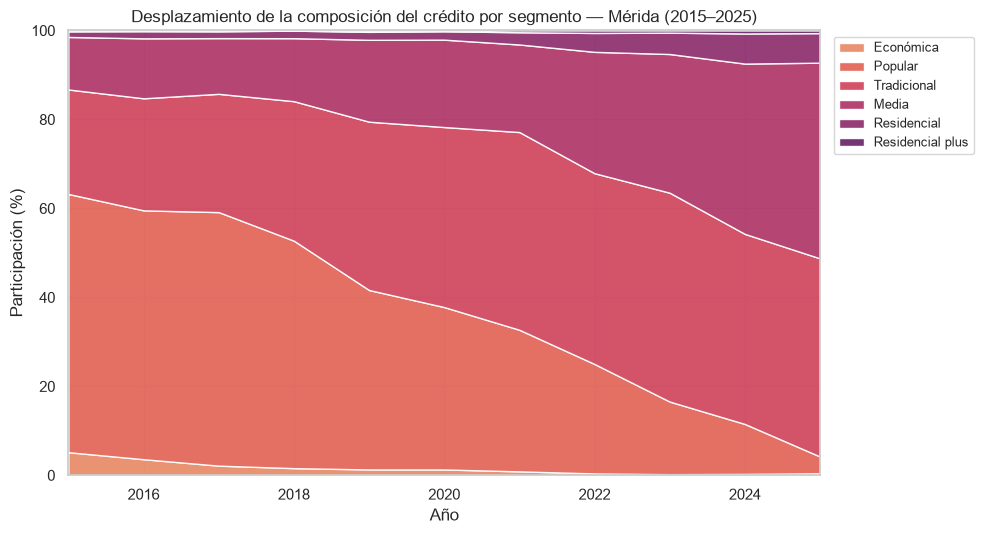

In [4]:
colores = sns.color_palette("flare", len(ORDEN))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.stackplot(share.index, [share[s] for s in ORDEN], labels=ORDEN, colors=colores, alpha=0.95)
ax.set(title="Desplazamiento de la composición del crédito por segmento — Mérida (2015–2025)",
       ylabel="Participación (%)", xlabel="Año", xlim=(2015, 2025), ylim=(0, 100))
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "corrimiento_segmentos.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparación directa 2015 vs 2025

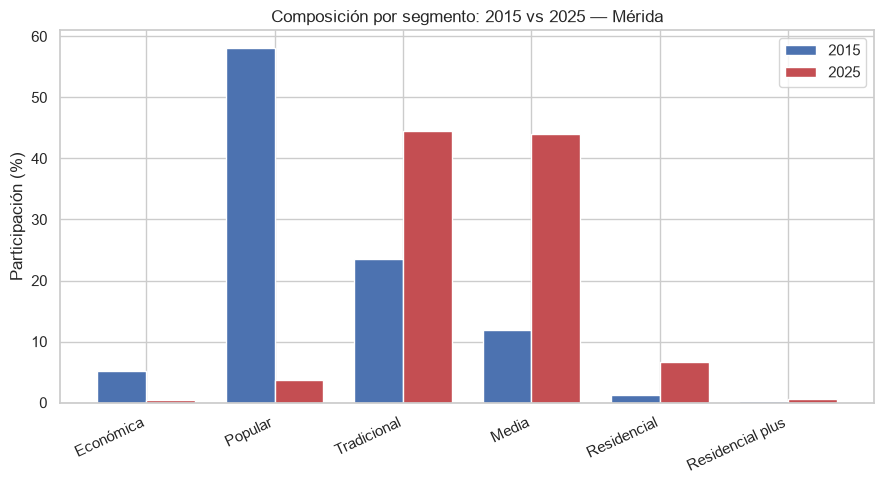

In [5]:
comp = share.loc[[2015, 2025]].T.reindex(ORDEN)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ORDEN)); w = 0.38
ax.bar(x - w/2, comp[2015], w, label="2015", color="#4C72B0")
ax.bar(x + w/2, comp[2025], w, label="2025", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(ORDEN, rotation=25, ha="right")
ax.set(ylabel="Participación (%)", title="Composición por segmento: 2015 vs 2025 — Mérida")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "mezcla_2015_vs_2025.png", dpi=150, bbox_inches="tight")
plt.show()

## Hallazgos del bloque 1

- **Desplazamiento hacia segmentos de mayor valor.** La composición del crédito pasó de estar
  dominada por **Popular** (58% en 2015) a concentrarse en **Tradicional** (44%) y **Media**
  (44%) en 2025. Popular descendió a ~4% y Económica prácticamente desapareció (5% → 0.4%).
- **En número de créditos:** Popular −96% (3,426 → 152) y Económica −94% (306 → 18) se
  contrajeron con fuerza; Media +155% (697 → 1,775) y Residencial +262% (74 → 268) crecieron.
- **Lectura de acceso:** el financiamiento formal en Mérida se desplazó hacia vivienda de mayor
  valor, y el segmento bajo casi desaparece del crédito.

**Advertencia metodológica (ver `docs/decisiones.md`):** el rango de pesos de cada segmento se
actualiza cada año con la inflación, pero en Mérida los precios de la vivienda crecieron más
rápido que la inflación. Por eso una misma casa puede terminar clasificada en un segmento más
alto con el tiempo solo porque subió de precio, sin ser una vivienda distinta. Así, una parte
del desplazamiento observado podría deberse a cómo se clasifica la vivienda, y no a un cambio
real del mercado. El bloque 3 (traducción a pesos) ayudará a separar lo real de lo aparente.

## 2. Flujo de crédito y crédito promedio por segmento

Cuánto dinero fluye por año y cómo se comporta el crédito promedio (monto / acciones) en cada
segmento. Recordatorio (`docs/decisiones.md`): `monto` es el crédito financiado, no el valor de
la vivienda.

### Flujo total de crédito por año

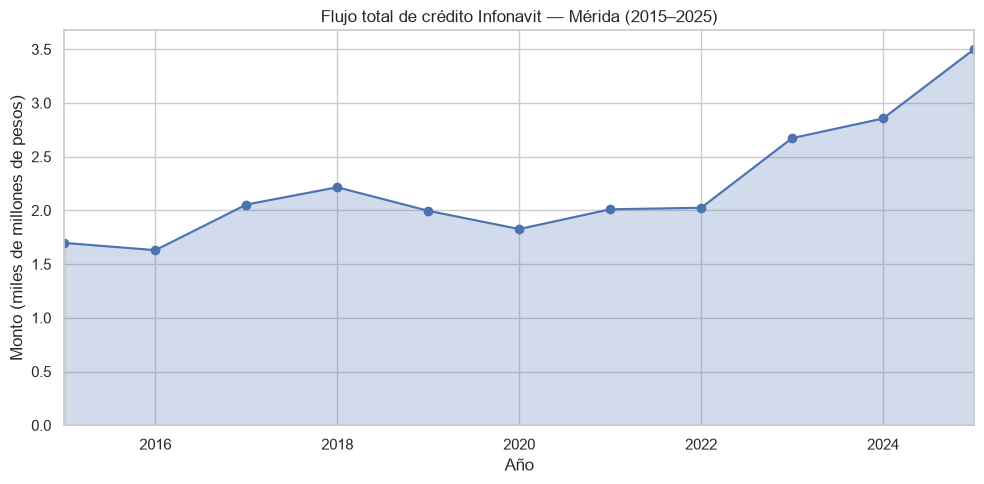

In [6]:
flujo = clasif.groupby("anio")["monto"].sum() / 1e9  # miles de millones

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(flujo.index, flujo.values, alpha=0.25, color="#4C72B0")
ax.plot(flujo.index, flujo.values, marker="o", color="#4C72B0")
ax.set(title="Flujo total de crédito Infonavit — Mérida (2015–2025)",
       ylabel="Monto (miles de millones de pesos)", xlabel="Año", xlim=(2015, 2025))
ax.set_ylim(0, None)
fig.tight_layout()
fig.savefig(OUT / "flujo_credito.png", dpi=150, bbox_inches="tight")
plt.show()

### Crédito promedio por segmento

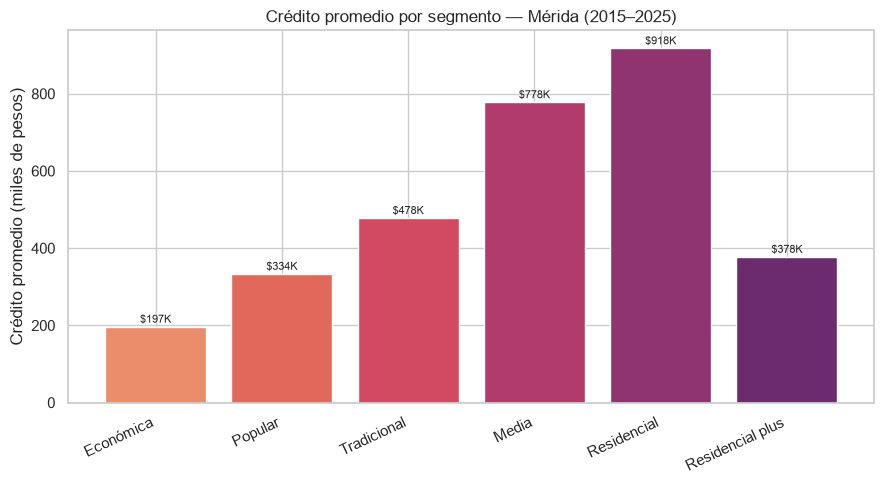

In [7]:
prom_seg = (
    clasif.groupby("segmento")
    .apply(lambda d: d["monto"].sum() / d["acciones"].sum(), include_groups=False)
    .reindex(ORDEN)
) / 1e3  # miles de pesos

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(ORDEN)), prom_seg.values, color=sns.color_palette("flare", len(ORDEN)))
ax.set_xticks(range(len(ORDEN))); ax.set_xticklabels(ORDEN, rotation=25, ha="right")
ax.set(ylabel="Crédito promedio (miles de pesos)",
       title="Crédito promedio por segmento — Mérida (2015–2025)")
for i, v in enumerate(prom_seg.values):
    ax.text(i, v + 10, f"${v:,.0f}K", ha="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "credito_promedio_segmento.png", dpi=150, bbox_inches="tight")
plt.show()

## Hallazgos del bloque 2

- **El flujo de crédito casi se duplicó:** de \\$1.70 a \\$3.50 miles de millones de pesos entre 2015 y 2025 (+106%), consistente con el desplazamiento hacia segmentos de mayor valor.
- **El crédito promedio asciende con el segmento**, de ~\\$197 K (económica) a ~\\$918 K (residencial)… **salvo en residencial plus, que cae a ~\\$378 K.** Esto no significa que esas viviendas valgan menos: el crédito Infonavit tiene un tope, y en la gama más alta el comprador cubre el resto por fuera del crédito.
- **Implicación:** el `monto` funciona como aproximación del valor solo en los segmentos bajos y medios; en la gama alta subestima el valor y conviene apoyarse en el rango del segmento (bloque 3).